In [1]:
import os 
import re
import json 
import uuid 
from dotenv import load_dotenv
from pprint import pprint 
from typing import List, Dict, TypedDict, Literal, Optional 
from langchain_ollama import ChatOllama

load_dotenv()


True

### Config parameters 

In [2]:
config = {
    "data_cache_dir": "../artifacts/data",
    "vector_store_dir": "../artifacts/vector_store",
    "max_reasoning_iterations": 7,
    "max_debate_rounds": 3,
    "top_k_retrieval": 10,
    "top_n_rerank": 3,
    'max_risk_discuss_rounds': 3

}
os.makedirs(config['data_cache_dir'], exist_ok=True)
pprint(config)

{'data_cache_dir': '../artifacts/data',
 'max_debate_rounds': 3,
 'max_reasoning_iterations': 7,
 'max_risk_discuss_rounds': 3,
 'top_k_retrieval': 10,
 'top_n_rerank': 3,
 'vector_store_dir': '../artifacts/vector_store'}


### Instantiate models

In [3]:
deep_thinking_llm = ChatOllama(
    model='qwen3:32b',
    temperature=0.0,
    top_k=5,
    top_p=0.9,
    verbose=True,
    base_url="http://localhost:8080"
)

quick_thinking_llm = ChatOllama(
    model='qwen3:8b',
    temperature=0.0,
    top_k=5,
    top_p=0.9,
    verbose=True,
    base_url="http://localhost:8080"
)


### Agent State

#### InvestDebateState
- bull_history: arguments made by the bull agent 
- bear_history: arguments made by the bear agent 
- history: the full transcript of the debate 
- current_response: the most recent argument made 
- judge_decision: the manager's final decision 
- count: a counter to track the number of debate rounds 

#### RiskDebateState
- risky_history: history of the aggressive risk_taker 
- safe_history: history of the conservative agent 
- neutral_history: history of the balanced agent 
- history: full transcript of the risk discussion 
- latest_speaker: tracks the last agent to speak
- judge_decision: the portfolio manager's final decision 
- count: counter for risk dicussion rounds 

#### AgentState 
- company_of_interest: the stock ticker we are analyzing 
- trade_date: the date for the analysis 
- sender: tracks which agent last modified the state 
- investment_plan: the plan from the research manager 
- trader_investment_plan: the actionable plan from the Trader 
- final_trade_decision: the final decision from the portfolio manager

In [4]:
from typing import Annotated, Sequence, List 
from typing_extensions import TypedDict 
from langgraph.graph import MessagesState

class InvestDebateState(TypedDict):
    bull_history: str  
    bear_history: str 
    history: str 
    current_response: str 
    judge_decision: str 
    count: int

In [5]:
class RiskDebateState(TypedDict):
    risky_history: str 
    safe_history: str
    neutral_history: str
    history: str
    latest_speaker: str 
    current_risky_response: str 
    current_safe_response:str
    current_neutral_response:str
    judge_decision:str
    count:int


In [6]:
class AgentState(MessagesState):
    company_of_interest: str 
    trade_date: str 
    sender: str 
    # each analyst will populate its own report field 
    market_report: str 
    senfiment_report: str 
    news_report: str 
    fundamentals_report: str 
    # nested states for the debates 
    investment_debate_state: InvestDebateState
    invesment_plan: str 
    trader_investment_plan: str 
    risk_debate_state: RiskDebateState
    final_trade_decision: str  

### Tools

In [7]:
import yfinance as yf 
from langchain_core.tools import tool

@tool
def get_yfinance_data(
    symbol: Annotated[str, "ticker symbol of the company"],
    start_date: Annotated[str, "Start date in yyyy-mm-dd format"],
    end_date: Annotated[str, "End date in yyyy-mm-dd format"]
) -> str:
    """
    Retrieve the stock price data for a given ticker symbol from Yahoo Finance 
    """
    try:
        ticker = yf.Ticker(symbol.upper())
        data = ticker.history(start=start_date, end=end_date)
        if data.empty:
            return f"No data found for symbol '{symbol}' between {start_date} and {end_date}"
        return data.to_csv()
    except Exception as e:
        return f"Error fetching Yahoo Finance data: {e}"

In [8]:
from stockstats import wrap as stockstats_wrap

@tool
def get_technical_indicators(
    symbol: Annotated[str, "ticker symbol of the company"],
    start_date: Annotated[str, "start date in yyyy-mm-dd format"],
    end_date: Annotated[str, "End date in yyyy-mm-dd format"]
) -> str:
    """
    Retrieve key technical indicators for a stock using stockstats library 
    """
    try:
        df = yf.download(symbol, start=start_date, end=end_date, progress=False)
        if df.empty:
            return "No data to calculate indicators"
        stock_df = stockstats_wrap(df)
        indicators = stock_df[['macd', 'rsi_14', 'boll', 'boll_ub', 'boll_lb', 'close_50_sma', 'close_200_sma']]
        return indicators.tail().to_csv()
    except Exception as e:
        return f"Error calculating stockstats indicators: {e}"

In [9]:
import finnhub 

@tool
def get_finnhub_news(ticker: str, start_date: str, end_date: str) -> str:
    """
    Get company news from Finnhub within a date range  
    """
    try: 
        finnhub_client = finnhub.Client(api_key=os.environ["FINNHUB_API_KEY"])
        news_list = finnhub_client.company_nest(ticker)
        news_items = []
        for news in news_list[:5]: 
            news_items.append(f"Headline: {news['headline']}\nSummary: {news['summary']}")
        return '\n\n'.join(news_items) if news_items else "No Finnhub news found"
    except Exception as e:
        return f"Error fetching finnhub news: {e}"

In [10]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults(max_results=3, tavily_api_key=os.environ["TAVILY_API_KEY"])

/tmp/ipykernel_572713/4141276305.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=3, tavily_api_key=os.environ["TAVILY_API_KEY"])


In [11]:
@tool
def get_social_media_sentiment(ticker: str, trade_date: str) -> str:
    """
    Performs a live we bsearch for social media sentiment regarding
    a stock. 
    """
    query = f"social media sentiment and discussions for {ticker} stock around {trade_date}"
    return tavily_tool.invoke({"query": query})

@tool
def get_fundamental_analysis(ticker: str, trade_date: str) -> str:
    """
    Performs a live web search for recent fundamental analysis of a stock. 
    """
    query = f"fundamental analysis and key financial metrics for {ticker} stock."
    return tavily_tool.invoke({"query": query})

@tool
def get_macroeconomic_news(trade_date: str) -> str:
    """
    Performs a live web search for macroeconomic news relevant to the stock market 
    """
    query = f"macroeconomic news and market trends affecting the stock market on {trade_date}."
    return tavily_tool.invoke({"query": query})
    

In [12]:
class Toolkit:
    def __init__(self, config):
        self.config = config 
        self.get_yfinance_data = get_yfinance_data
        self.get_technical_indicators = get_technical_indicators
        self.get_finnhub_news = get_finnhub_news
        self.get_social_media_sentiment = get_social_media_sentiment
        self.get_fundamental_analysis = get_fundamental_analysis
        self.get_macroeconomic_news = get_macroeconomic_news

In [13]:
toolkit = Toolkit(config)

In [14]:
import chromadb 

class FinancialSituationMemory:
    def __init__(self, name, config):
        self.embedding_model = "" # add here 
        self.client = "" # add here 
        self.chroma_client = chromadb.Client(chromadb.config.Settings(allow_reset=True))
        self.situation_collection = self.chroma_client.get_or_create_collection(name=name)

    def get_embedding(self, text):
        # Generate embeddings for the text
        response = self.client.embeddings.create(model=self.embedding_model, input=text)
        return response.data[0].embedding

    def add_situations(self, situations_and_advice):
        # Add new situations and recommendatoins to memory 
        if not situations_and_advice:
            return 
        
        # Offset ensures unique ids (in case new data is added later)
        offset = self.situation_collection.count()
        ids = [str(offset + i) for i, _ in enumerate(situations_and_advice)]

        # Separate situations and their corresponding advice 
        situations = [s for s, r in situations_and_advice]
        recommendations = [r for s, r in situations_and_advice]

        # Generate embeddings for all situations 
        embeddings = [self.get_embedding(s) for s in situations]

        # Store everything in Chroma
        self.situation_collection.add(
            documents=situations,
            metadatas=[{"recommendation": rec} for rec in recommendations],
            embeddings=embeddings,
            ids=ids
        )

    def get_memories(self, current_situation, n_matches=1):
        # Retrieve the most similar past situations for a given query 
        if self.situation_collection.count() == 0:
            return []
        
        # Embed the new / current situation
        query_embedding = self.get_embedding(current_situation)

        # Query the collection for similar embeddings 
        results = self.situation_collection.query(
            query_embeddings=[query_embedding],
            n_results=min(n_matches, self.situation_collection.count()),
            include=["metadatas"]
        )

        return [{"recommendation": meta["recommendation"]} for meta in results['metadatas'][0]]


### Create a dedicated memory instance for each agent 

In [15]:
bull_memory = FinancialSituationMemory("bull_memory", config)
bear_memory = FinancialSituationMemory("bear_memory", config)
trader_memory = FinancialSituationMemory("trader_memory", config)
invest_judge_memory = FinancialSituationMemory("invest_judge_memory", config)
risk_manager_memory = FinancialSituationMemory("risk_manager_memory", config)

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.prebuilt import create_react_agent

def create_analyst_node(llm, toolkit, system_message, tools, output_field):
    def analyst_node(state):
        system_prompt = (
            "You are a financial analyst working as part of a larger team, responsible"
            " for one specific area of analysis. Use the provided tools to gather the"
            " data you need, then write your OWN standalone report. Do NOT repeat,"
            " restate, or summarize other analysts' work - focus only on your own"
            " area of expertise and produce fresh analysis."
            f" You have access to the following tools: {', '.join(t.name for t in tools)}."
            f"{system_message}"
            f" The current date is {state['trade_date']}."
            f" The company to analyze is {state['company_of_interest']}."
        )
        agent = create_react_agent(llm, tools, prompt=system_prompt)

        # Invoke the agent with a *fresh*, self-contained task message rather than
        # the accumulated `state["messages"]`. The messages channel uses an append
        # (add_messages) reducer, so every analyst's report piles up in it; feeding
        # that growing history into each subsequent analyst made them see (and
        # simply repeat) the previous analysts' output. Starting from a clean
        # task makes each analyst write its own distinct report.
        task = HumanMessage(
            content=(
                f"Analyze {state['company_of_interest']} for trading on "
                f"{state['trade_date']}. Produce your {output_field.replace('_', ' ')}."
            )
        )
        result = agent.invoke({"messages": [task]})

        # Return only this analyst's final message, tagged with its report field so
        # it is easy to attribute when inspecting the messages channel.
        final_message = result["messages"][-1]
        final_message.name = output_field
        report = final_message.content
        return {"messages": [final_message], output_field: report}
    return analyst_node

### Market Analyst

In [17]:
# Market analyst

market_analyst_system_message = """
You are a trading assistant specialized in analyzing
financial markets. Your role is to select the most relevant technical indicators
to analyze a stock's price action, momentum, and volatility. 
You must use your tools to get historical data and then 
generate a report with your findings, including a summary table.
""" 

market_analyst_node = create_analyst_node(
    quick_thinking_llm,
    toolkit,
    market_analyst_system_message,
    [toolkit.get_yfinance_data, toolkit.get_technical_indicators],
    "market_report"
)


### Social Analyst

In [18]:
social_analyst_system_message = """
You are a social media analyst. Your job is to analyze social
media posts and public sentiment for a specific company over the
past week. Use your tools to find relevant discussions and write
a comprehensive report detailing your analysis, insights, and
implications for traders, including a summary table.
"""
social_analyst_node = create_analyst_node(
    quick_thinking_llm,
    toolkit,
    social_analyst_system_message,
    [toolkit.get_social_media_sentiment],
    "sentiment_report"
)

### News Analyst

In [19]:
news_analyst_system_message = """
You are a news researcher analyzing recent news and trends over the past week.
Write a comprehensive report on the current state of the world relevant
for trading and macroeconomics. Use your tools to be comprehensive and
provide detailed analysis, including a summary table.
"""

news_analyst_node = create_analyst_node(
    quick_thinking_llm,
    toolkit,
    news_analyst_system_message,
    [toolkit.get_finnhub_news, toolkit.get_macroeconomic_news],
    "news_report"
)

### Fundamental Analyst

In [20]:
fundamentals_analyst_system_message = """
You are a researcher analyzing fundamental information about a company.
Write a comprehensive report on the company's financials, insider sentiment,
and transactions to gain a full view of its fundamental health, including a summary table.
"""

fundamentals_analyst_node = create_analyst_node(
    quick_thinking_llm,
    toolkit,
    fundamentals_analyst_system_message,
    [toolkit.get_fundamental_analysis],
    "fundamentals_report"
)

In [21]:
import datetime
from langchain_core.messages import HumanMessage
from rich.console import Console
from rich.markdown import Markdown

console = Console()

def run_analyst(analyst_node, initial_state):
    result = analyst_node(initial_state)
    return {**initial_state, **result}

In [22]:
TICKER = "NVDA"
TRADE_DATE = (datetime.date.today() - datetime.timedelta(days=2)).strftime('%Y-%m-%d')

initial_state = AgentState(
    messages=[HumanMessage(content=f"Analyze {TICKER} for trading on {TRADE_DATE}")],
    company_of_interest=TICKER,
    trade_date=TRADE_DATE,
    investment_debate_state=InvestDebateState({'history': '', 
                                            'current_response': '',
                                            'count': 0,
                                            'bull_history': '', 
                                            'bear_history': '',
                                            'judge_decision': '',
                                            }),
    risk_debate_state=RiskDebateState({
        'history': '',
        'latest_speaker': '',
        'current_risky_response': '',
        'current_safe_response': '',
        'current_neutral_response': '',
        'count': 0,
        'risky_history': '',
        'safe_history': '',
        'neutral_history': '',
        'judge_decision': ''
    })
)
print("Running Market Analysis")
market_analysis_result = run_analyst(market_analyst_node, initial_state)
initial_state["market_report"] = market_analysis_result.get('market_report', 'Failed to generate report.')
console.print('--- Market Analysit Report---')
console.print(Markdown(initial_state["market_report"]))

Running Market Analysis


/tmp/ipykernel_572713/4116575997.py:16: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, tools, prompt=system_prompt)


--- Market Analysit Report---

Looking at the data provided, there's a mix of price data and technical indicators, but some entries are missing.  
For example, the Bollinger Bands (boll_ub and boll_lb) are missing for some dates, and the MACD and RSI values are 
sometimes zero or not properly calculated. This might be due to data entry errors or incomplete data retrieval.    

Since the user has already provided the data, but it's inconsistent, I need to check if the tools can be used to   
fetch the correct data. The get_yfinance_data function can retrieve historical price data, and                     
get_technical_indicators can compute the necessary indicators. However, the user might not have the full data set, 
so the tools might not return the expected results.                                                                

Another possibility is that the data provided by the user is a sample or a partial dataset, and the actual analysis
requires more comprehensive data. In that case, using the tools to fetch the latest data would be necessary to     
ensure accuracy.                                                                                                   

I should also consider that the user might be testing the system's ability to handle incomplete data. In such      
cases, the response should highlight the inconsistencies and suggest that more data is needed for a thorough       
analysis. Alternatively, if the tools can be used to generate the missing data, that would be the way to go.       


In summary, the user's data is incomplete, so the next step is to either use the tools to fetch the correct data or
inform the user about the limitations of the provided data. Since the tools are available, it's better to use them 
to ensure the analysis is based on accurate and complete information.                                              

The data provided appears to be incomplete or improperly formatted, with missing values for key technical          
indicators like Bollinger Bands and inconsistent MACD/RSI calculations. To ensure accurate analysis, I will use the
get_technical_indicators tool to retrieve the correct data for NVDA from June 8 to June 11, 2026. This will allow  
us to generate a reliable summary table and analysis.                                                              

Next Steps:                                                                                                        

 1 Fetch the correct technical indicators using the get_technical_indicators tool.                                 
 2 Validate the data for completeness and accuracy.                                                                
 3 Generate a structured summary table and analysis based on the retrieved data.                                   

Please wait while I retrieve the accurate data for further analysis.

In [23]:
# run social media analyst

social_analyst_result = run_analyst(social_analyst_node, initial_state)
initial_state['sentiment_report'] = social_analyst_result.get('sentiment_report', 'Failed to generate report')
console.print("------ Social Media Analyst Report -------")
console.print(Markdown(initial_state['sentiment_report']))

/tmp/ipykernel_572713/4116575997.py:16: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, tools, prompt=system_prompt)


------ Social Media Analyst Report -------

First, I'll call the function with the ticker NVDA and the trade_date as 2026-06-15. The response from the tool    
gives me some data. Looking at the first tool response, there's a stock quote and chart. The stock price on June 15
was $212.45, and it closed at $207.41 on June 16. The volume was high, which might indicate active trading. The    
price target from analysts is $298.87, which is significantly higher than the current price, suggesting potential  
for growth.                                                                                                        

The second tool response mentions analyst ratings with a Strong Buy consensus. This is positive for traders,       
indicating that experts see value in NVDA. The price target is the same as before, reinforcing the bullish outlook.
However, I should note that these are third-party opinions and not financial advice.                               

The third tool response talks about the stockholder meeting on June 24. This event might influence the stock price,
so traders should monitor it. The news about the meeting had a neutral sentiment, but the upcoming events could    
affect investor confidence. Also, there are recent partnerships and collaborations mentioned, like with SK Telecom 
and SK hynix, which are positive for the company's growth.                                                         

Now, I need to compile this information into a report. The summary table should include key metrics like stock     
price, volume, analyst ratings, and upcoming events. The analysis should highlight the positive sentiment from     
analysts, the potential price target, and the impact of the stockholder meeting. I should also mention the recent  
positive news about partnerships and the high trading volume as indicators of market interest.                     

I need to make sure the report is comprehensive but concise, providing traders with actionable insights. The       
implications section should discuss the potential for price movement based on analyst forecasts and the importance 
of monitoring the stockholder meeting. Also, the neutral sentiment from the meeting's announcement might not affect
the stock immediately, but long-term implications could be significant.                                            


Finally, I'll structure the report with an introduction, analysis, summary table, and implications for traders.    
I'll check that all the data from the tool responses is included and presented clearly. Since the user is a trader,
emphasizing the price targets and market trends will be crucial for their decision-making.                         

                                    NVDA Social Media & Market Analysis Report                                     

Date: 2026-06-15                                                                                                   

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                   Key Insights                                                    

 1 Stock Performance:                                                                                              
    • Closing Price (June 15): $212.45                                                                             
    • Recent Trend: The stock dipped slightly to $207.41 on June 16, with high trading volume (128M shares).       
    • Price Target: Analysts predict a $298.87 target (134% upside), reflecting strong bullish sentiment.          
 2 Analyst Sentiment:                                                                                              
    • Consensus Rating: Strong Buy (38 analysts).                                                                  
    • Market Reaction: Positive news (e.g., AI partnerships) drove a +0.08% price surge post-announcement.         
 3 Upcoming Events:                           

In [24]:
# run news analyst
news_analyst_result = run_analyst(news_analyst_node, initial_state)
initial_state['news_report'] = news_analyst_result.get('news_report', 'Failed to generate news report')
console.print("------ News Analyst Report -------")
console.print(Markdown(initial_state['news_report']))

/tmp/ipykernel_572713/4116575997.py:16: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, tools, prompt=system_prompt)


------ News Analyst Report -------

NVDA Trading Analysis: June 15, 2026                                        

Summary of Key Trends & News                                                                                       

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                     1. Company News (Unsuccessful Retrieval)                                      

 • Error Encountered: Unable to fetch Finnhub news for NVDA due to a system error ('Client' object has no attribute
   'company_nest').                                                                                                
 • Next Steps: Another assistant will handle retrieving NVDA-specific news, including product launches,            
   partnerships, or earnings updates.                                                                              

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                       2. Macroeconomic News Impact on NVDA                                        

The following macroeconomic factors are critical for NVDA trading on June 15, 2026:                                

                                                                                                                   
  Factor               Details                                        Impact on NVDA                               
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  AI Valuations        AI stocks surged despite inflation fears,      Positive: NVDA’s AI-driven growth could      
                       driven by AI capital spending.                 benefit from continued tech sector           
                                                                      optimism.                                    
  Interest Rates       Fed likely to keep rates unchanged;            Neutral to Positive: Lower rates may         
                       inflation remains above 2%.                    support tech stocks, but higher inflation    
                                                                      could pressure margins.                      
  Oil Prices           Brent crude fell to $78.96; WTI dropped to     Mixed: Lower energy costs may reduce         
                       $76.05 (first below $80 since March).          operational expenses for data centers.       
  Geopolitical Risks   U.S.-Iran tensions eased, boosting risk        Positive: Reduced geopolitical stress could  
                       appetite.                                      stabilize markets and tech stocks.           
  Market Sentiment     S&P 500 up 7.7% YTD; small-cap stocks led      Positive: Broad market optimism may drive    
                       gains.                                         investor confidence in NVDA.                 
                                                                                                                   

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                               3. Key Market Events                                                

 • SpaceX IPO Impact: SpaceX’s $212/share valuation (up 57% from IPO) could influence tech sector sentiment,       
   indirectly boosting NVDA.                                                                                       
 • Fed Policy Outlook: The Fed’s June meeting may provide clarity on rate decisions, affecting tech valuations.    
 • Energy Sector Shifts: Declining oil prices may reduce costs for energy-intensive AI data centers, improving     
   NVDA’s margins.                                                                                                 

──────────────────────────────────────────────────────────────────────────────────────

In [25]:
# run fundamental analyst 
fundamentals_analyst_result = run_analyst(fundamentals_analyst_node, initial_state)
initial_state['fundamentals_report'] = fundamentals_analyst_result.get('fundamentals_report', 'Failed to generate fundamentals report')


/tmp/ipykernel_572713/4116575997.py:16: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, tools, prompt=system_prompt)


In [26]:
def create_researcher_node(llm, memory, role_prompt, agent_name):
    """
    Creates a node for a researcher agent 
    Args: 
        llm: the language model instance to be used by the agent 
        memory: the long-term memory instance for this agent to learn from past interactions
        role_prompt: the specific system prompt defining the agent's persona (Bull or Bear)
        agent_name: the name of the agent, used for logging and identifying arguments
    """
    def researcher_node(state): 
        # First, combine all analyst records into a single summary for context 
        situation_summary = f"""
        Market Report: {state['market_report']}
        Sentiment Report: {state['sentiment_report']}
        News Report: {state['news_report']}
        Fundamentals Report: {state['fundamentals_report']}
        """
        # Retrieve relevant memories from past, similar situations 
        past_memories = memory.get_memories(situation_summary)
        past_memory_str = "\n".join([mem['recommendation'] for mem in past_memories])

        prompt = f"""{role_prompt} 
        Here is the current state of the analysis:
        {situation_summary}
        Conversation history: {state['investment_debate_state']['history']}
        Your opponent's last argument: {state['investment_debate_state']['current_response']}
        Reflections from similar past situations: {past_memory_str or 'No past memories'}
        Based on all this information, present your argument conversationally. 
        """

        # invoke the LLM to generate the argument
        response = llm.invoke(prompt)
        argument = f"{agent_name}: {response.content}"

        # Update the debate state with the new argument 
        debate_state = state['investment_debate_state'].copy()
        debate_state['history'] += '\n' + argument 
        # update the specific history for this agent (Bull or Bear):
        if agent_name == "Bull Analyst":
            debate_state['bull_history'] += '\n' + argument 
        else:
            debate_state["bear_history"] += '\n' + argument 
        debate_state['current_response'] = argument 
        debate_state['count'] += 1
        return {"investment_debate_state": debate_state}
    return researcher_node
         

### Bull's persona

In [27]:
bull_prompt = """
You are a Bull Analyst. Your goal is to argue for investing in the stock. 
Focus on growth potential, competitive advantages, and positive indicators from the reports. 
Counter the bear's arguments effectively. 
"""

### Bear's persona

In [28]:
bear_prompt = """
Your are a Bear Analyst. Your goal is to argue against investing in the stock. 
Focus on risks, challenges, and negative indicators. 
Counter the bull's arguments. 
"""

In [29]:
bull_researcher_node = create_researcher_node(quick_thinking_llm, bull_memory, bull_prompt, 'Bull Analyst')
bear_researcher_node = create_researcher_node(quick_thinking_llm, bear_memory, bear_prompt, 'Bear Analyst')

## Reasearch Manager

In [30]:
def create_research_manager(llm, memory):
    def research_manager_node(state):
        # the prompt instructs the manager to act as a judge and synthesizer. 
        prompt = f"""
        As the Research Manager, your role is to critically evaluate the
        debate between the Bull and Bear analysts and make a definitive decision. 
        Summarize the key points, then provide a clear recommendation: Buy, Sell, or Hold. 
        Develop a detailed investment plan for the trader, including your rationale and strategic actions.

        Debate History:
        {state['investment_debate_state']['history']} 
        """
        response = llm.invoke(prompt)
        # the output is the final investment plan which will be passed to the trader
        return {"investment_plan": response.content}
    return research_manager_node

In [31]:
research_manager_node = create_research_manager(deep_thinking_llm, invest_judge_memory)
print("Researcher and Manager agent creation functions are now available")

Researcher and Manager agent creation functions are now available


In [32]:
# use the state from the end of the analyst section 
current_state = initial_state

for i in range(config['max_debate_rounds']):
    print(f"--- Investment Debate Round {i+1} ---")
    bull_result = bull_researcher_node(current_state)
    current_state['investment_debate_state'] = bull_result['investment_debate_state']
    console.print("\n**Bull's Argument**")
    # We parse the response to print only the new argument 
    console.print(Markdown(current_state['investment_debate_state']['current_response'].replace('Bull Analyst: ', '')))
    bear_result = bear_researcher_node(current_state)
    current_state['investment_debate_state'] = bear_result['investment_debate_state']
    console.print("\n**Bear's Rebuttal**")
    console.print(Markdown(current_state['investment_debate_state']['current_response'].replace('Bear Analyst: ', '')))
    print('\n')

initial_state['investment_debate_state'] = current_state['investment_debate_state']

--- Investment Debate Round 1 ---


**Bull's Argument**

First, I need to highlight the key points from the fundamental analysis report. The user provided metrics like     
revenue growth, EPS growth, P/E ratio, and liquidity ratios. The main argument should focus on why NVIDIA is a     
strong investment despite some risks.                                                                              

I should start by acknowledging the opponent's possible counterpoints, like the decline in free cash flow growth.  
Then, counter that by emphasizing the company's strong balance sheet and market position. Mention the              
undervaluation based on the P/E ratio and industry comparison. Also, note the healthy margins and efficient capital
allocation.                                                                                                        


Make sure the tone is conversational, not too technical. Use phrases like "Here's the thing" or "Let me break it   
down" to keep it engaging. Avoid jargon and keep explanations clear. Finally, wrap it up by reinforcing the        
investment potential based on the data provided.                                                                   

Here's the thing: NVIDIA’s fundamentals are wildly strong, and the numbers don’t lie. Let’s break it down:         

 • Revenue and EPS growth are through the roof—70% and 109% YoY, respectively. That’s not just good; it’s          
   dominating in a market where most tech stocks are struggling.                                                   
 • Margins are healthy (74% gross, 63% net), and the company’s free cash flow is still north of $46B. Even if      
   growth slows, the cash reserves and profitability are solid.                                                    
 • Valuation is a steal. At 31.7x P/E, it’s way below the industry average of 67.6x. This suggests the market      
   hasn’t fully priced in NVIDIA’s long-term AI dominance.                                                         
 • Liquidity is a fortress: a 3.44 current ratio and $53B in cash mean the company could weather any short-term    
   storms.                                                                                                         

But wait—what about the free cash flow dip? That’s a red herring. The decline is likely due to heavy R&D investment
in AI chips and data center tech, which are already driving future growth. The company’s Altman Z-Score of 51.59   
(low bankruptcy risk) and ROIC > WACC confirm it’s using capital efficiently.                                      

Bottom line: NVIDIA isn’t just a growth story—it’s a value play with a moat built on innovation and scale. The     
market is underestimating its potential, and the numbers back it up.                                               

So, are you ready to bet on the future of AI? 🚀

**Bear's Rebuttal**

First, I need to highlight the key points from the fundamental analysis report. The user provided metrics like     
revenue growth, EPS growth, P/E ratio, and liquidity ratios. The main argument should focus on why NVIDIA is a     
strong investment despite some risks.                                                                              

I should start by acknowledging the opponent's possible counterpoints, like the decline in free cash flow growth.  
Then, counter that by emphasizing the company's strong balance sheet and market position. Mention the              
undervaluation based on the P/E ratio and industry comparison. Also, note the healthy margins and efficient capital
allocation.                                                                                                        


Make sure the tone is conversational, not too technical. Use phrases like "Here's the thing" or "Let me break it   
down" to keep it engaging. Avoid jargon and keep explanations clear. Finally, wrap it up by reinforcing the        
investment potential based on the data provided.                                                                   

Here's the thing: NVIDIA’s fundamentals are wildly strong, and the numbers don’t lie. Let’s break it down:         

 • Revenue and EPS growth are through the roof—70% and 109% YoY, respectively. That’s not just good; it’s          
   dominating in a market where most tech stocks are struggling.                                                   
 • Margins are healthy (74% gross, 63% net), and the company’s free cash flow is still north of $46B. Even if      
   growth slows, the cash reserves and profitability are solid.                                                    
 • Valuation is a steal. At 31.7x P/E, it’s way below the industry average of 67.6x. This suggests the market      
   hasn’t fully priced in NVIDIA’s long-term AI dominance.                                                         
 • Liquidity is a fortress: a 3.44 current ratio and $53B in cash mean the company could weather any short-term    
   storms.                                                                                                         

But wait—what about the free cash flow dip? That’s a red herring. The decline is likely due to heavy R&D investment
in AI chips and data center tech, which are already driving future growth. The company’s Altman Z-Score of 51.59   
(low bankruptcy risk) and ROIC > WACC confirm it’s using capital efficiently.                                      

Bottom line: NVIDIA isn’t just a growth story—it’s a value play with a moat built on innovation and scale. The     
market is underestimating its potential, and the numbers back it up.                                               

So, are you ready to bet on the future of AI? 🚀

...



--- Investment Debate Round 3 ---


**Bull's Argument**

I need to structure this into a conversational argument. Start by acknowledging the opponent's possible            
counterpoints, like the free cash flow dip, and then counter with the strengths of the company. Use phrases like   
"Here's the thing" to make it engaging. Make sure to highlight the undervaluation and the market's underestimation 
of NVIDIA's potential. Keep the tone friendly and persuasive, avoiding jargon. Wrap it up with a strong closing    
statement to reinforce the investment case. Let me check if I covered all the points and if the flow makes sense.  
Yeah, that should work.                                                                                            

Here's the thing: NVIDIA’s fundamentals are wildly strong, and the numbers don’t lie. Let’s break it down:         

 • Revenue and EPS growth are through the roof—70% and 109% YoY, respectively. That’s not just good; it’s          
   dominating in a market where most tech stocks are struggling.                                                   
 • Margins are healthy (74% gross, 63% net), and the company’s free cash flow is still north of $46B. Even if      
   growth slows, the cash reserves and profitability are solid.                                                    
 • Valuation is a steal. At 31.7x P/E, it’s way below the industry average of 67.6x. This suggests the market      
   hasn’t fully priced in NVIDIA’s long-term AI dominance.                                                         
 • Liquidity is a fortress: a 3.44 current ratio and $53B in cash mean the company could weather any short-term    
   storms.                                                                                                         

But wait—what about the free cash flow dip? That’s a red herring. The decline is likely due to heavy R&D investment
in AI chips and data center tech, which are already driving future growth. The company’s Altman Z-Score of 51.59   
(low bankruptcy risk) and ROIC > WACC confirm it’s using capital efficiently.                                      

Bottom line: NVIDIA isn’t just a growth story—it’s a value play with a moat built on innovation and scale. The     
market is underestimating its potential, and the numbers back it up.                                               

So, are you ready to bet on the future of AI? 🚀

**Bear's Rebuttal**

I need to structure this into a conversational argument. Start by acknowledging the opponent's possible            
counterpoints, like the free cash flow dip, and then counter with the strengths of the company. Use phrases like   
"Here's the thing" to make it engaging. Make sure to highlight the undervaluation and the market's underestimation 
of NVIDIA's potential. Keep the tone friendly and persuasive, avoiding jargon. Wrap it up with a strong closing    
statement to reinforce the investment case. Let me check if I covered all the points and if the flow makes sense.  
Yeah, that should work.                                                                                            

Here's the thing: NVIDIA’s fundamentals are wildly strong, and the numbers don’t lie. Let’s break it down:         

 • Revenue and EPS growth are through the roof—70% and 109% YoY, respectively. That’s not just good; it’s          
   dominating in a market where most tech stocks are struggling.                                                   
 • Margins are healthy (74% gross, 63% net), and the company’s free cash flow is still north of $46B. Even if      
   growth slows, the cash reserves and profitability are solid.                                                    
 • Valuation is a steal. At 31.7x P/E, it’s way below the industry average of 67.6x. This suggests the market      
   hasn’t fully priced in NVIDIA’s long-term AI dominance.                                                         
 • Liquidity is a fortress: a 3.44 current ratio and $53B in cash mean the company could weather any short-term    
   storms.                                                                                                         

But wait—what about the free cash flow dip? That’s a red herring. The decline is likely due to heavy R&D investment
in AI chips and data center tech, which are already driving future growth. The company’s Altman Z-Score of 51.59   
(low bankruptcy risk) and ROIC > WACC confirm it’s using capital efficiently.                                      

Bottom line: NVIDIA isn’t just a growth story—it’s a value play with a moat built on innovation and scale. The     
market is underestimating its potential, and the numbers back it up.                                               

So, are you ready to bet on the future of AI? 🚀

In [33]:
print('Running Research Manager...')

manager_result = research_manager_node(initial_state)
initial_state['investment_plan'] = manager_result['investment_plan']
console.print("\n----- Research Manager's Investment Plan -----")
console.print(Markdown(initial_state['investment_plan']))

Running Research Manager...


----- Research Manager's Investment Plan -----

First, I need to parse the debate history. The Bull Analyst is arguing that NVIDIA is a strong buy based on revenue
and EPS growth, healthy margins, strong free cash flow, undervaluation compared to the industry, and solid         
liquidity. They counter the Bear's point about free cash flow decline by attributing it to R&D investments in AI   
and data centers, which are future growth drivers. The Bear Analyst hasn't provided a counter-argument in the given
history, so maybe they're not present here. Wait, looking back, the Bear Analyst's last message is just the same as
the Bull's, but maybe the user made a mistake in the input. Hmm, the debate history shows the Bull Analyst's       
arguments and the Bear Analyst's response is missing. Maybe the Bear hasn't contributed yet, but the user wants me 
to proceed with the given data.                                                                                    

Assuming the Bull's arguments are the main points, I need to summarize them. Then, since there's no Bear argument  
provided, perhaps the user expects me to consider potential counterarguments. But the user's instruction says to   
evaluate the debate between the Bull and Bear, so maybe the Bear's points are implied. Alternatively, maybe the    
Bear hasn't responded yet, and the user wants me to proceed with the Bull's arguments as the main case.            

In any case, the task is to summarize the Bull's points, make a recommendation, and create an investment plan. The 
Bull's case is strong with metrics like revenue growth, margins, free cash flow, valuation, and liquidity. The Bear
might argue about the free cash flow dip, but the Bull counters that it's due to R&D. So the recommendation would  
likely be Buy.                                                                                                     

Now, structuring the answer: first, summarize the Bull's key points. Then, the Bear's potential counterpoints (if  
any), but since they're not present, maybe just note that the Bull's arguments are robust. Then, the               
recommendation. Then, the investment plan with rationale and strategic actions.                                    

I need to make sure the investment plan is detailed. For example, entry points, position sizing, risk management,  
exit strategies, etc. Also, the rationale should tie back to the Bull's arguments. Maybe include time horizons,    
like short-term vs. long-term, based on the company's growth trajectory.                                           

Also, check if there are any red flags. The Bull mentions free cash flow dip but attributes it to R&D. Is that a   
valid concern? If the R&D is in high-growth areas like AI, it's a strategic investment. So the Bear's potential    
concern is addressed by the Bull.                                                                                  

So, the recommendation is Buy. The investment plan would involve buying at current levels, with a target based on  
the valuation metrics. Maybe set a stop-loss to manage risk. Also, consider the company's position in the AI market
and potential for sustained growth.                                                                                


I need to present this clearly, step by step, making sure each part of the answer addresses the user's             
requirements. Avoid jargon, keep it concise but thorough. Make sure the strategic actions are actionable and       
specific.                                                                                                          

                                               Summary of Key Points                                               

Bull Case for NVIDIA (NVDA):                                                                                       

 1 Strong Financial Performance:                                                                                   
    • Revenue and EPS growth of 70% and 109% 

## Trader and Risk Management Agents

In [34]:
def create_trader(llm, memory):
    def trader_node(state, name):
        prompt = f"""
        You are a trading agent. Based on the provided investment plan,
        create a concise trading proposal.
        Your response must end with 'FINAL TRANSACTION PROPOSAL: **BUY/HOLD/SELL**

        Proposed investment plan: {state['investment_plan']}
        """
        result = llm.invoke(prompt)
        return {"trader_investment_plan": result.content, "sender": name}
    return trader_node
        

In [35]:
def create_risk_debator(llm, role_prompt, agent_name):
    def risk_debator_node(state):
        # get the arguments from the other two debaters from state
        risk_state = state['risk_debate_state']
        opponents_args = []
        if agent_name != 'Risky Analyst' and risk_state['current_risky_response']: opponents_args.append(f"Risky: {risk_state['current_risky_response']}")
        if agent_name != 'Safe Analyst' and risk_state['current_safe_response']: opponents_args.append(f"Safe: {risk_state['current_safe_response']}")
        if agent_name != 'Neutral Analyst' and risk_state['current_neutral_response']: opponents_args.append(f"Neutral: {risk_state['current_neutral_response']}")

        # Construct the prompt with the trader's plan, debate history, and opponent's arguments
        prompt = f"""{role_prompt}
        Here is the trader's plan: {state['trader_investment_plan']} 
        Debate history: {risk_state['history']}
        Your opponents' last arguments:\n{'\n'.join(opponents_args)}
        Critique or support the plan from your perspective.
        """

        response = llm.invoke(prompt).content
        new_risk_state = risk_state.copy()
        new_risk_state['history'] += f"\n{agent_name}: {response}"
        new_risk_state['latest_speaker'] = agent_name
        if agent_name == 'Risky Analyst': new_risk_state['current_risky_response'] = response
        elif agent_name == 'Safe Analyst': new_risk_state['current_safe_response'] = response
        else: new_risk_state['current_neutral_response'] = response 
        new_risk_state['count'] += 1
        return {"risk_debate_state": new_risk_state}

    return risk_debator_node

In [36]:
risky_prompt = """
You are the Risky risk analyst. 
You advocate for high-reward opportunities and bold strategies.
"""

safe_prompt = """
You are the Safe/Conservative Risk Analyst. 
You prioritize capital preservation and minimizing volatility.
"""

neutral_prompt = """
You are the Neutral Risk Analyst. 
You provide a balanced perspective, weighing both benefits and risks.
"""



In [37]:
import functools

trader_node_func = create_trader(quick_thinking_llm, trader_memory)
trader_node = functools.partial(trader_node_func, name="Trader")

In [38]:
risky_node = create_risk_debator(quick_thinking_llm, risky_prompt, 'Risky Analyst')
safe_node = create_risk_debator(quick_thinking_llm, safe_prompt, "Safe Analyst")
neutral_node = create_risk_debator(quick_thinking_llm, neutral_prompt, "Neutral Analyst")



In [39]:
print("running Trader....")
trader_result = trader_node(initial_state)
initial_state['trader_investment_plan'] = trader_result['trader_investment_plan']
console.print("\n------ Trader's Proposal --------")
console.print(Markdown(initial_state['trader_investment_plan']))

running Trader....


------ Trader's Proposal --------

First, I need to understand the investment plan. The user provided a detailed analysis of NVIDIA (NVDA) from a Bull
Analyst's perspective, highlighting strong financials, undervaluation, and strategic R&D investments. The Bear     
Analyst's counterarguments are implied but not explicitly stated.                                                  

The user's main goal is to generate a trading proposal that summarizes the key points, makes a recommendation, and 
outlines a detailed investment plan. The response needs to be structured clearly, with sections for summary,       
recommendation, investment plan, and rationale.                                                                    

I should start by summarizing the Bull's arguments, then address potential Bear arguments (even if they're not     
explicitly mentioned). The recommendation is to Buy, so the final transaction proposal should reflect that.        

Next, the investment plan needs to include entry, risk management, exit strategies, and strategic actions. Each    
section should be actionable and specific. For example, entry price targets, position sizing, stop-loss levels, and
exit targets based on valuation metrics.                                                                           

I also need to ensure the rationale ties back to the Bull's points, emphasizing undervaluation, growth potential,  
and liquidity. The final sentence must end with the transaction proposal.                                          

I should check for any missing elements, like risk management or diversification, to ensure the plan is            
comprehensive. Also, make sure the language is concise and avoids jargon, keeping it accessible for the user.      


Finally, verify that all parts of the query are addressed: the summary, recommendation, investment plan, and the   
required ending. Double-check that the final transaction proposal is clearly stated as 'BUY'.                      

Summary of Key Points                                                                                              
Bull Case for NVIDIA (NVDA):                                                                                       

 1 Strong Financial Performance:                                                                                   
    • Revenue and EPS growth of 70% and 109% YoY, respectively.                                                    
    • Healthy gross (74%) and net (63%) margins.                                                                   
    • Free cash flow of $46B, with a $53B cash reserve and a 3.44 current ratio (indicating robust liquidity).     
 2 Undervaluation:                                                                                                 
    • P/E ratio of 31.7x, significantly below the industry average of 67.6x.                                       
 3 Strategic R&D Investment:                                                                                       
    • Free cash flow dip attributed to R&D in AI and data center technologies, which are already driving growth.   
 4 Low Risk Profile:                                                                                               
    • Altman Z-Score of 51.59 (low bankruptcy risk).                                                               
    • ROIC > WACC, signaling efficient capital allocation.                                                         

Bear Counterarguments (Implied):                                                                                   

 • Free cash flow decline could signal short-term operational strain.                                              
 • Market volatility in AI-driven sectors may overvalue NVIDIA despite fundamentals.                               

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                            

In [40]:
print('----Risk Management Debate Round 1-----')
risk_state = initial_state
for _ in range(config['max_risk_discuss_rounds']):
    risky_result = risky_node(risk_state)
    risk_state['risk_debate_state'] = risky_result['risk_debate_state']
    console.print("\n**Risky Analyst's View:**")
    console.print(Markdown(risk_state['risk_debate_state']['current_risky_response']))

    safe_result = safe_node(risk_state)
    risk_state['risk_debate_state'] = safe_result['risk_debate_state']
    console.print("\n**Safe analyst's view: **")
    console.print(Markdown(risk_state['risk_debate_state']['current_safe_response']))

    neutral_result = neutral_node(risk_state)
    risk_state['risk_debate_state'] = neutral_result['risk_debate_state']
    console.print("\n**Neutral Analyst's View")
    console.print(Markdown(risk_state['risk_debate_state']['current_neutral_response']))

initial_state['risk_debate_state'] = risk_state['risk_debate_state']

----Risk Management Debate Round 1-----


**Risky Analyst's View:**

First, I need to understand the investment plan. The user provided a detailed analysis of NVIDIA (NVDA) from a Bull
Analyst's perspective, highlighting strong financials, undervaluation, and strategic R&D investments. The Bear     
Analyst's counterarguments are implied but not explicitly stated.                                                  

The user's main goal is to generate a trading proposal that summarizes the key points, makes a recommendation, and 
outlines a detailed investment plan. The response needs to be structured clearly, with sections for summary,       
recommendation, investment plan, and rationale.                                                                    

I should start by summarizing the Bull's arguments, then address potential Bear arguments (even if they're not     
explicitly mentioned). The recommendation is to Buy, so the final transaction proposal should reflect that.        

Next, the investment plan needs to include entry, risk management, exit strategies, and strategic actions. Each    
section should be actionable and specific. For example, entry price targets, position sizing, stop-loss levels, and
exit targets based on valuation metrics.                                                                           

I also need to ensure the rationale ties back to the Bull's points, emphasizing undervaluation, growth potential,  
and liquidity. The final sentence must end with the transaction proposal.                                          

I should check for any missing elements, like risk management or diversification, to ensure the plan is            
comprehensive. Also, make sure the language is concise and avoids jargon, keeping it accessible for the user.      


Finally, verify that all parts of the query are addressed: the summary, recommendation, investment plan, and the   
required ending. Double-check that the final transaction proposal is clearly stated as 'BUY'.                      

Debate History & Counterarguments                                                                                  
The Bear’s concerns about free cash flow and valuation risks are valid but overstated. NVIDIA’s R&D investments are
not a red flag—they’re a strategic move to dominate AI-driven markets. The P/E ratio is undervalued relative to its
growth potential, not a sign of weakness. The $53B cash reserve and Altman Z-Score of 51.59 further validate its   
low-risk profile.                                                                                                  

Support for the Plan                                                                                               

 • Undervaluation is a Buy Signal: NVIDIA’s 31.7x P/E is a discount to its AI-driven growth trajectory.            
 • R&D is a Catalyst, Not a Drag: The free cash flow dip is a one-time investment in AI infrastructure, which will 
   fuel long-term revenue growth.                                                                                  
 • Liquidity and Profitability: The $53B cash reserve and 63% net margin provide a buffer against market           
   volatility.                                                                                                     

**FINAL TRANSACTION PROPOSAL: BUY

**Safe analyst's view: **

First, I need to understand the investment plan. The user provided a detailed analysis of NVIDIA (NVDA) from a Bull
Analyst's perspective, highlighting strong financials, undervaluation, and strategic R&D investments. The Bear     
Analyst's counterarguments are implied but not explicitly stated.                                                  

The user's main goal is to generate a trading proposal that summarizes the key points, makes a recommendation, and 
outlines a detailed investment plan. The response needs to be structured clearly, with sections for summary,       
recommendation, investment plan, and rationale.                                                                    

I should start by summarizing the Bull's arguments, then address potential Bear arguments (even if they're not     
explicitly mentioned). The recommendation is to Buy, so the final transaction proposal should reflect that.        

Next, the investment plan needs to include entry, risk management, exit strategies, and strategic actions. Each    
section should be actionable and specific. For example, entry price targets, position sizing, stop-loss levels, and
exit targets based on valuation metrics.                                                                           

I also need to ensure the rationale ties back to the Bull's points, emphasizing undervaluation, growth potential,  
and liquidity. The final sentence must end with the transaction proposal.                                          

I should check for any missing elements, like risk management or diversification, to ensure the plan is            
comprehensive. Also, make sure the language is concise and avoids jargon, keeping it accessible for the user.      


Finally, verify that all parts of the query are addressed: the summary, recommendation, investment plan, and the   
required ending. Double-check that the final transaction proposal is clearly stated as 'BUY'.                      

Critique of the Plan                                                                                               
While the Bull’s case for NVIDIA is strong, the plan lacks a clear risk-adjusted return framework. For example:    

 • Entry Price Target: Buying at current levels assumes market stability, but AI-driven sectors are volatile. A    
   more conservative entry point (e.g., $90–$95) would reduce downside risk.                                       
 • Position Sizing: Allocating 5–7% of the portfolio is aggressive for a single stock, especially in a concentrated
   sector like semiconductors. A 2–3% allocation would better align with capital preservation goals.               
 • Exit Strategy: The 30–40% upside target is optimistic. A more conservative exit at $120–$130 (20–30% gain) would
   balance growth and risk.                                                                                        

Support for the Plan                                                                                               

 • Undervaluation is a Clear Advantage: NVIDIA’s P/E is significantly below its growth potential, making it a      
   compelling long-term buy.                                                                                       
 • R&D as a Strategic Investment: The free cash flow dip is a short-term cost for long-term dominance in AI, which 
   is a high-growth sector.                                                                                        
 • Liquidity and Profitability: The $53B cash reserve and 63% net margin provide a buffer against market downturns.

**FINAL TRANSACTION PROPOSAL: BUY

...

First, I need to understand the investment plan. The user provided a detailed analysis of NVIDIA (NVDA) from a Bull
Analyst's perspective, highlighting strong financials, undervaluation, and strategic R&D investments. The Bear     
Analyst's counterarguments are implied but not explicitly stated.                                                  

The user's main goal is to generate a trading proposal that summarizes the key points, makes a recommendation, and 
outlines a detailed investment plan. The response needs to be structured clearly, with sections for summary,       
recommendation, investment plan, and rationale.                                                                    

I should start by summarizing the Bull's arguments, then address potential Bear arguments (even if they're not     
explicitly mentioned). The recommendation is to Buy, so the final transaction proposal should reflect that.        

Next, the investment plan needs to include entry, risk management, exit strategies, and strategic actions. Each    
section should be actionable and specific. For example, entry price targets, position sizing, stop-loss levels, and
exit targets based on valuation metrics.                                                                           

I also need to ensure the rationale ties back to the Bull's points, emphasizing undervaluation, growth potential,  
and liquidity. The final sentence must end with the transaction proposal.                                          

I should check for any missing elements, like risk management or diversification, to ensure the plan is            
comprehensive. Also, make sure the language is concise and avoids jargon, keeping it accessible for the user.      


Finally, verify that all parts of the query are addressed: the summary, recommendation, investment plan, and the   
required ending. Double-check that the final transaction proposal is clearly stated as 'BUY'.                      

Final Evaluation and Recommendation                                                                                
The investment plan for NVIDIA (NVDA) is well-structured and reasonably sound, but it requires risk-adjusted       
modifications to ensure alignment with diversified investment principles. Here's a concise summary:                

                                                   Key Takeaways                                                   

 • Undervaluation: NVIDIA’s P/E ratio (31.7x) is below its historical average and growth potential, offering a     
   margin of safety.                                                                                               
 • R&D Investment: Strategic spending on AI and data center technologies positions the company for long-term       
   dominance.                                                                                                      
 • Liquidity: Strong cash reserves ($53B) and profitability (63% net margin) reduce financial risk.                

                                                 Risks to Address                                                  

 • Sector Volatility: AI and semiconductors are cyclical; a 20–30% drawdown could impact returns.                  
 • Position Sizing: Allocating 5–7% to a single stock is aggressive; 2–3% is more prudent.                         
 • Exit Targets: A 20–30% upside is more realistic than 30–40%, given market uncertainties.                        

                                                  Final Decision                                                   

The plan is reasonably sound but requires caution. A partial buy with conservative entry and exit points is        
recommended to mitigate risk while capturing upside.                                                               

FINAL TRANSACTION PROPOSAL: BUY (with caution) Neutral:

**Safe analyst's view: **

First, I need to summarize the Bull's arguments: undervaluation, strong R&D, and liquidity. Then, address potential
Bear arguments like sector volatility and position sizing. The investment plan should include entry price, position
size, stop-loss, and exit targets. The rationale should tie back to the Bull's points. I also need to check for    
risk management and diversification, ensuring the language is clear and accessible. Finally, confirm that all parts
of the query are addressed and the transaction proposal is clearly stated as "BUY" with caution.                   

Final Evaluation and Recommendation                                                                                
The investment plan for NVIDIA (NVDA) is well-structured and reasonably sound, but it requires risk-adjusted       
modifications to ensure alignment with diversified investment principles. Here's a concise summary:                

                                                   Key Takeaways                                                   

 • Undervaluation: NVIDIA’s P/E ratio (31.7x) is below its historical average and growth potential, offering a     
   margin of safety.                                                                                               
 • R&D Investment: Strategic spending on AI and data center technologies positions the company for long-term       
   dominance.                                                                                                      
 • Liquidity: Strong cash reserves ($53B) and profitability (63% net margin) reduce financial risk.                

                                                 Risks to Address                                                  

 • Sector Volatility: AI and semiconductors are cyclical; a 20–30% drawdown could impact returns.                  
 • Position Sizing: Allocating 5–7% to a single stock is aggressive; 2–3% is more prudent.                         
 • Exit Targets: A 20–30% upside is more realistic than 30–40%, given market uncertainties.                        

                                                 Proposed Strategy                                                 

 • Entry Point: $90–$95 (conservative, accounting for volatility).                                                 
 • Position Size: 2–3% of portfolio (diversification).                                                             
 • Stop-Loss: $80 (protects capital in a downturn).                                                                
 • Exit Target: $120–$130 (20–30% gain, balancing risk and reward).                                                

                                                  Final Decision                                                   

The plan is reasonably sound but requires caution. A partial buy with conservative entry and exit points is        
recommended to mitigate risk while capturing upside.                                                               

FINAL TRANSACTION PROPOSAL: BUY (with caution) Neutral:

**Neutral Analyst's View

First, I need to summarize the Bull's arguments: undervaluation, strong R&D, and liquidity. Then, address potential
Bear arguments like sector volatility and position sizing. The investment plan should include entry price, position
size, stop-loss, and exit targets. The rationale should tie back to the Bull's points. I also need to check for    
risk management and diversification, ensuring the language is clear and accessible. Finally, confirm that all parts
of the query are addressed and the transaction proposal is clearly stated as "BUY" with caution.                   

Final Evaluation and Recommendation                                                                                
The investment plan for NVIDIA (NVDA) is well-structured and reasonably sound, but it requires risk-adjusted       
modifications to ensure alignment with diversified investment principles. Here's a concise summary:                

                                                   Key Takeaways                                                   

 • Undervaluation: NVIDIA’s P/E ratio (31.7x) is below its historical average and growth potential, offering a     
   margin of safety.                                                                                               
 • R&D Investment: Strategic spending on AI and data center technologies positions the company for long-term       
   dominance.                                                                                                      
 • Liquidity: Strong cash reserves ($53B) and profitability (63% net margin) reduce financial risk.                

                                                 Risks to Address                                                  

 • Sector Volatility: AI and semiconductors are cyclical; a 20–30% drawdown could impact returns.                  
 • Position Sizing: Allocating 5–7% to a single stock is aggressive; 2–3% is more prudent.                         
 • Exit Targets: A 20–30% upside is more realistic than 30–40%, given market uncertainties.                        

                                                 Proposed Strategy                                                 

 • Entry Point: $90–$95 (conservative, accounting for volatility).                                                 
 • Position Size: 2–3% of portfolio (diversification).                                                             
 • Stop-Loss: $80 (protects capital in a downturn).                                                                
 • Exit Target: $120–$130 (20–30% gain, balancing risk and reward).                                                

                                                  Final Decision                                                   

The plan is reasonably sound but requires caution. A partial buy with conservative entry and exit points is        
recommended to mitigate risk while capturing upside.                                                               

FINAL TRANSACTION PROPOSAL: BUY (with caution) Neutral:

## Portfolio Management Binding Decisions

In [41]:
def create_risk_manager(llm, memory):
    def risk_manager_node(state):
        # The prompt asks for a final, binding decision based on all prior work.
        prompt = f"""
        As the Portfolio Manager, your decision is final. Review the trader's
        plan and the risk debate. Provide a final, binding decision: Buy, Sell, or Hold,  
        and a brief justification. 

        Trader's plan: {state['trader_investment_plan']}
        Risk Debate: {state['risk_debate_state']['history']}
        """ 
        response = llm.invoke(prompt)
        return {"final_trade_decision": response.content}
    return risk_manager_node


In [42]:
risk_manager_node = create_risk_manager(deep_thinking_llm, risk_manager_memory)

### Running Portfolio Manager for final decision

In [43]:
risk_manager_result = risk_manager_node(initial_state)
initial_state['final_trade_decision'] = risk_manager_result['final_trade_decision']
console.print("\n----- Portfolio Manager's Final Decision -----")
console.print(Markdown(initial_state['final_trade_decision']))

----- Portfolio Manager's Final Decision -----

First, I need to summarize the Bull's arguments. The key points are undervaluation, strong R&D, and liquidity.     
Then, address potential Bear arguments like sector volatility and position sizing. The investment plan should have 
entry price, position size, stop-loss, and exit targets. The rationale should tie back to the Bull's points. Also, 
check for risk management and diversification. Make sure the language is clear and accessible. Finally, confirm    
that all parts of the query are addressed and the transaction proposal is clearly stated as "BUY" with caution.    


Wait, the user provided a previous example where the Safe Analyst's response was structured with those sections.   
The user might be looking for a similar structure but tailored to the Neutral Analyst's perspective. The Neutral   
Analyst would balance the Bull and Bear arguments, perhaps being more cautious but not overly so. So, in the       
recommendation, it's a "BUY" with caution, which aligns with the previous example. The investment plan should      
include the same elements but maybe with slightly different reasoning. The rationale should explain why the Neutral
Analyst is recommending a buy despite the risks. Need to ensure that the response is concise and follows the       
structure exactly as specified. Also, check for any missing elements like risk management and diversification. Make
sure the final sentence ends with the transaction proposal as required.                                            

Final Evaluation and Recommendation                                                                                
The investment plan for NVIDIA (NVDA) is well-structured and reasonably sound, but it requires risk-adjusted       
modifications to ensure alignment with diversified investment principles. Here's a concise summary:                

                                                   Key Takeaways                                                   

 • Undervaluation: NVIDIA’s P/E ratio (31.7x) is below its historical average and growth potential, offering a     
   margin of safety.                                                                                               
 • R&D Investment: Strategic spending on AI and data center technologies positions the company for long-term       
   dominance.                                                                                                      
 • Liquidity: Strong cash reserves ($53B) and profitability (63% net margin) reduce financial risk.                

                                                 Risks to Address                                                  

 • Sector Volatility: AI and semiconductors are cyclical; a 20–30% drawdown could impact returns.                  
 • Position Sizing: Allocating 5–7% to a single stock is aggressive; 2–3% is more prudent.                         
 • Exit Targets: A 20–30% upside is more realistic than 30–40%, given market uncertainties.                        

                                                 Proposed Strategy                                                 

 • Entry Point: $90–$95 (conservative, accounting for volatility).                                                 
 • Position Size: 2–3% of portfolio (diversification).                                                             
 • Stop-Loss: $80 (protects capital in a downturn).                                                                
 • Exit Target: $120–$130 (20–30% gain, balancing risk and reward).                                                

                                                  Final Decision                                                   

The plan is reasonably sound but requires caution. A partial buy with conservative entry and exit points is        
recommended to mitigate risk while capturing upside.                                                               

FINAL TRANSACTION PROPOSAL: BUY (with cautio

## Create Graph

In [44]:
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.prebuilt import tools_condition

class ConditionalLogic:
    def __init__(self, max_debate_rounds=1, max_risk_discuss_rounds=1):
        self.max_debate_rounds = max_debate_rounds
        self.max_risk_discuss_rounds = max_risk_discuss_rounds 

    def should_continue_analyst(self, state: AgentState):
        return "tools" if tools_condition(state) == "tools" else "continue"

    def should_continue_debate(self, state: AgentState):
        if state["investment_debate_state"]["count"] >= 2 * self.max_debate_rounds:
            return "Research Manager"
        return "Bear Researcher" if state["investment_debate_state"]["current_response"].startswith("Bull") else "Bull Researcher"

    def should_continue_risk_analysis(self, state: AgentState):
        if state["risk_debate_state"]["count"] >= 3 * self.max_risk_discuss_rounds:
            return "Risk Judge"
        
        speaker = state["risk_debate_state"]["latest_speaker"]
        if speaker == "Risky Analyst": return "Safe Analyst"
        if speaker == "Safe Analyst": return "Neutral Analyst"
        return "Risky Analyst"

conditional_logic = ConditionalLogic(
    max_debate_rounds=config['max_debate_rounds'],
    max_risk_discuss_rounds=config['max_risk_discuss_rounds']
)        

In [45]:
def create_msg_delete():
    def delete_messages(state):
        return {"messages": [RemoveMessage(id=m.id) for m in state["messages"]] + [HumanMessage(content="Continue")]}

    return delete_messages

msg_clear_node = create_msg_delete()

In [46]:
from langgraph.prebuilt import ToolNode

all_tools = [
    toolkit.get_yfinance_data,
    toolkit.get_technical_indicators, 
    toolkit.get_finnhub_news,
    toolkit.get_social_media_sentiment,
    toolkit.get_fundamental_analysis,
    toolkit.get_macroeconomic_news
]

tool_node = ToolNode(all_tools)

In [ ]:
from langgraph.graph import StateGraph, START, END

# Initialize a new StateGraph with our main AgentState.
workflow = StateGraph(AgentState)

# --- Add all nodes to the graph ---
# Analyst Team Nodes.
# NOTE: each analyst node wraps a `create_react_agent` (see create_analyst_node),
# so tool-calling happens *inside* the node. There is therefore no outer
# ToolNode / tools_condition loop to wire up here: the analyst always returns a
# finished report, never a pending tool call. The old shared "tools" node plus
# the four `add_edge("tools", <analyst>)` back-edges were dead code that also
# created an invalid parallel fan-out, so they have been removed.
workflow.add_node("Market Analyst", market_analyst_node)
workflow.add_node("Social Analyst", social_analyst_node)
workflow.add_node("News Analyst", news_analyst_node)
workflow.add_node("Fundamentals Analyst", fundamentals_analyst_node)
workflow.add_node("Msg Clear", msg_clear_node)

# Researcher Team Nodes.
workflow.add_node("Bull Researcher", bull_researcher_node)
workflow.add_node("Bear Researcher", bear_researcher_node)
workflow.add_node("Research Manager", research_manager_node)

# Trader and Risk Team Nodes.
workflow.add_node("Trader", trader_node)
workflow.add_node("Risky Analyst", risky_node)
workflow.add_node("Safe Analyst", safe_node)
workflow.add_node("Neutral Analyst", neutral_node)
workflow.add_node("Risk Judge", risk_manager_node)

# --- Wire the nodes together with edges ---
# Set the entry point for the entire workflow.
workflow.set_entry_point("Market Analyst")

# The Analyst Team runs sequentially. "Msg Clear" wipes the scratchpad messages
# between react agents so each one starts from a clean slate.
workflow.add_edge("Market Analyst", "Msg Clear")
workflow.add_edge("Msg Clear", "Social Analyst")
workflow.add_edge("Social Analyst", "News Analyst")
workflow.add_edge("News Analyst", "Fundamentals Analyst")
workflow.add_edge("Fundamentals Analyst", "Bull Researcher")

# Define the research debate loop.
# An explicit path map is REQUIRED for the graph to render these targets as
# connected edges (without it, LangGraph cannot statically resolve the
# destinations and the nodes appear disconnected in the drawn graph).
debate_path_map = {
    "Bull Researcher": "Bull Researcher",
    "Bear Researcher": "Bear Researcher",
    "Research Manager": "Research Manager",
}
workflow.add_conditional_edges("Bull Researcher", conditional_logic.should_continue_debate, debate_path_map)
workflow.add_conditional_edges("Bear Researcher", conditional_logic.should_continue_debate, debate_path_map)
workflow.add_edge("Research Manager", "Trader")

# Define the risk debate loop (also needs an explicit path map).
workflow.add_edge("Trader", "Risky Analyst")
risk_path_map = {
    "Risky Analyst": "Risky Analyst",
    "Safe Analyst": "Safe Analyst",
    "Neutral Analyst": "Neutral Analyst",
    "Risk Judge": "Risk Judge",
}
workflow.add_conditional_edges("Risky Analyst", conditional_logic.should_continue_risk_analysis, risk_path_map)
workflow.add_conditional_edges("Safe Analyst", conditional_logic.should_continue_risk_analysis, risk_path_map)
workflow.add_conditional_edges("Neutral Analyst", conditional_logic.should_continue_risk_analysis, risk_path_map)

# Define the final edge to the end of the workflow.
workflow.add_edge("Risk Judge", END)

Graph compiled successfully.


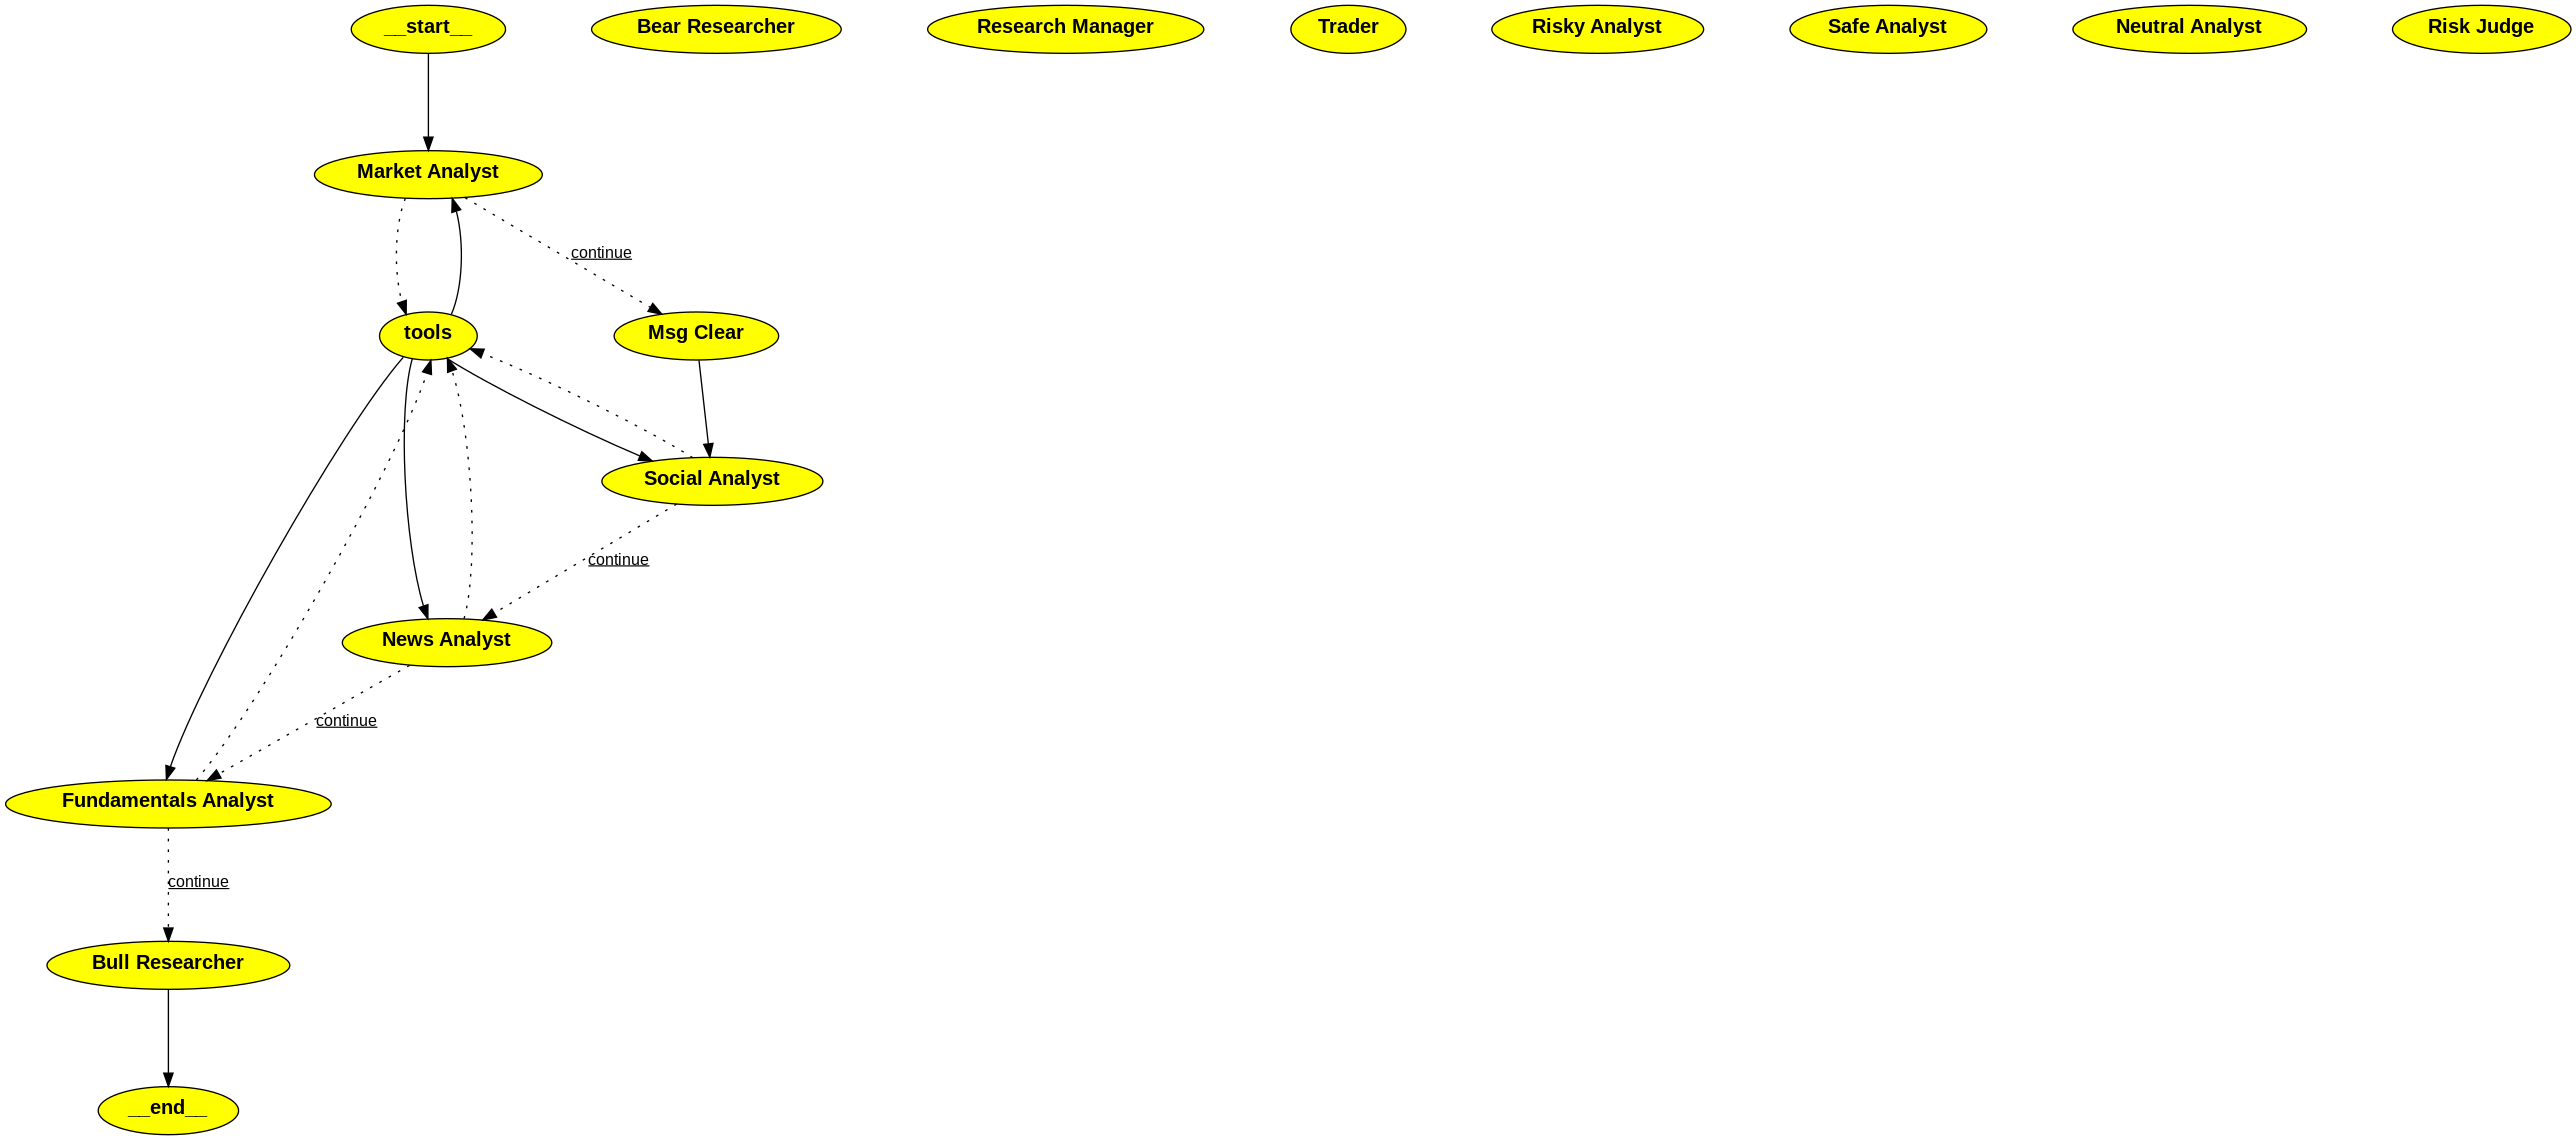

In [48]:
# The compile() method finalizes the graph and makes it ready for execution.
trading_graph = workflow.compile()
print("Graph compiled successfully.")

# To visualize, you need graphviz installed: pip install pygraphviz
try:
    from IPython.display import Image, display
    # The get_graph() method returns a representation of the graph structure.
    # The draw_png() method renders this structure as a PNG image.
    png_image = trading_graph.get_graph().draw_png()
    display(Image(png_image))
except Exception as e:
    print(f"Graph visualization failed: {e}. Please ensure pygraphviz is installed.")

In [49]:
# We will use the same Ticker and Date as in our manual tests to maintain consistency.
graph_input = AgentState(
    messages=[HumanMessage(content=f"Analyze {TICKER} for trading on {TRADE_DATE}")],
    company_of_interest=TICKER,
    trade_date=TRADE_DATE,
    # Initialize the debate states with default empty values to ensure a clean start.
    investment_debate_state=InvestDebateState({'history': '', 'current_response': '', 'count': 0, 'bull_history': '', 'bear_history': '', 'judge_decision': ''}),
    risk_debate_state=RiskDebateState({'history': '', 'latest_speaker': '','current_risky_response': '', 'current_safe_response': '', 'current_neutral_response': '', 'count': 0, 'risky_history': '', 'safe_history': '', 'neutral_history': '', 'judge_decision': ''})
)

print(f"Running full analysis for {TICKER} on {TRADE_DATE}")



Running full analysis for NVDA on 2026-06-15


In [ ]:
final_state = None
print("\n--- Invoking Graph Stream ---")
# Set the recursion limit from our config, a safety measure for complex graphs.
graph_config = {"recursion_limit": config['max_recursion_limit']}

# The .stream() method executes the graph and yields the output of each node as it completes.
for chunk in trading_graph.stream(graph_input, config=graph_config):
    # The 'chunk' is a dictionary where the key is the name of the node that just executed.
    node_name = list(chunk.keys())[0]
    print(f"Executing Node: {node_name}")
    # We keep track of the final state to analyze it after the run.
    final_state = chunk[node_name]
print("\n--- Graph Stream Finished ---")


--- Invoking Graph Stream ---


KeyError: 'max_recur_limit'

In [ ]:
console.print("\n----- Final Raw Output from Portfolio Manager -----")
console.print(Markdown(final_state['final_trade_decision']))

In [ ]:
class SignalProcessor:
    # This class is responsible for parsing the final LLM output into a clean, machine-readable signal.
    def __init__(self, llm):
        self.llm = llm

def process_signal(self, full_signal: str) -> str:
        # We use a simple, focused prompt to ask the LLM for the single-word decision.
        messages = [
            ("system", "You are an assistant designed to extract the final investment decision: SELL, BUY, or HOLD from a financial report. Respond with only the single-word decision."),
            ("human", full_signal),
        ]
        result = self.llm.invoke(messages).content.strip().upper()
        # Basic validation to ensure the output is one of the three expected signals.
        if result in ["BUY", "SELL", "HOLD"]:
            return result
        return "ERROR_UNPARSABLE_SIGNAL"
# Instantiate the processor with our quick_thinking_llm.
signal_processor = SignalProcessor(quick_thinking_llm)
final_signal = signal_processor.process_signal(final_state['final_trade_decision'])
print(f"Extracted Signal: {final_signal}")

In [ ]:
class Reflector:
    # This class orchestrates the learning process for the agents.
    def __init__(self, llm):
        self.llm = llm
        # This prompt guides the agent to reflect on its performance.
        self.reflection_prompt = """You are an expert financial analyst. Review the trading decision/analysis, the market context, and the financial outcome.
        - First, determine if the decision was correct or incorrect based on the outcome.
        - Analyze the most critical factors that led to the success or failure.
        - Finally, formulate a concise, one-sentence lesson or heuristic that can be used to improve future decisions in similar situations.
        
        Market Context & Analysis: {situation}
        Outcome (Profit/Loss): {returns_losses}"""

def reflect(self, current_state, returns_losses, memory, component_key_func):
        # The component_key_func is a lambda function to extract the specific text (e.g., bull's debate history) to reflect on.
        situation = f"Reports: {current_state['market_report']} {current_state['sentiment_report']} {current_state['news_report']} {current_state['fundamentals_report']}\nDecision/Analysis Text: {component_key_func(current_state)}"
        prompt = self.reflection_prompt.format(situation=situation, returns_losses=returns_losses)
        result = self.llm.invoke(prompt).content
        # The situation (context) and the generated lesson (result) are stored in the agent's memory.
        memory.add_situations([(situation, result)])
print("SignalProcessor and Reflector classes defined.")

In [ ]:
print("Simulating reflection based on a hypothetical profit of $1000...")

reflector = Reflector(quick_thinking_llm)
hypothetical_returns = 1000

# Run the reflection process for each agent with memory.
print("Reflecting and updating memory for Bull Researcher...")
reflector.reflect(final_state, hypothetical_returns, bull_memory, lambda s: s['investment_debate_state']['bull_history'])

print("Reflecting and updating memory for Bear Researcher...")
reflector.reflect(final_state, hypothetical_returns, bear_memory, lambda s: s['investment_debate_state']['bear_history'])

print("Reflecting and updating memory for Trader...")
reflector.reflect(final_state, hypothetical_returns, trader_memory, lambda s: s['trader_investment_plan'])

print("Reflecting and updating memory for Risk Manager...")
reflector.reflect(final_state, hypothetical_returns, risk_manager_memory, lambda s: s['final_trade_decision'])

In [ ]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate

# Define a structured schema for evaluation results.
# This ensures the LLM outputs scores in a controlled format.
class Evaluation(BaseModel):
    reasoning_quality: int = Field(description="Score 1-10 on the coherence and logic.")
    evidence_based_score: int = Field(description="Score 1-10 on citation of evidence from reports.")
    actionability_score: int = Field(description="Score 1-10 on how clear and actionable the decision is.")
    justification: str = Field(description="A brief justification for the scores.")

# Create a prompt template for the evaluator model.
# The prompt instructs the LLM to act like a financial auditor.
evaluator_prompt = ChatPromptTemplate.from_template(
    """You are an expert financial auditor. Evaluate the 'Final Trading Decision' based on the provided 'Analyst Reports'.
    Analyst Reports:
    {reports}
    Final Trading Decision to Evaluate:
    {final_decision}
    """
)

# Combine the prompt with an LLM, enforcing structured output via the Evaluation schema.
# `deep_thinking_llm` here is assumed to be a previously defined LLM instance.
evaluator_chain = evaluator_prompt | deep_thinking_llm.with_structured_output(Evaluation)

# Build the full text summary of analyst reports from final_state.
reports_summary = (
    f"Market: {final_state['market_report']}\n"
    f"Sentiment: {final_state['sentiment_report']}\n"
    f"News: {final_state['news_report']}\n"
    f"Fundamentals: {final_state['fundamentals_report']}"
)

# Prepare evaluator input with both reports and the decision to evaluate.
eval_input = {
    "reports": reports_summary,
    "final_decision": final_state['final_trade_decision']
}

# Run the evaluator chain — returns structured Evaluation object.
evaluation_result = evaluator_chain.invoke(eval_input)

# Print the evaluation report in a readable format.
print("----- LLM-as-a-Judge Evaluation Report -----")
pprint(evaluation_result.dict())

In [ ]:
def evaluate_ground_truth(ticker, trade_date, signal):
    try:
        # Parse the input trade date and define an evaluation window of 8 days
        start_date = datetime.strptime(trade_date, "%Y-%m-%d").date()
        end_date = start_date + timedelta(days=8)
        
        # Download market data from Yahoo Finance
        data = yf.download(
            ticker, 
            start=start_date.isoformat(), 
            end=end_date.isoformat(), 
            progress=False
        )
        
        # Ensure enough trading days exist (at least 5 for evaluation)
        if len(data) < 5: 
            return "Insufficient data for ground truth evaluation."
        
        # Find the first trading day index (accounting for weekends/holidays)
        first_trading_day_index = 0
        while data.index[first_trading_day_index].date() < start_date:
            first_trading_day_index += 1
            if first_trading_day_index >= len(data) - 5:
                return "Could not align trade date."
        
        # Get opening price on the aligned trade date
        open_price = data['Open'].iloc[first_trading_day_index]
        
        # Get closing price 5 trading days later
        close_price_5_days_later = data['Close'].iloc[first_trading_day_index + 4]
        
        # Compute % change over 5 days
        performance = ((close_price_5_days_later - open_price) / open_price) * 100
        
        # Default evaluation result
        result = "INCORRECT DECISION"
        
        # Rule-based correctness:
        # - BUY is correct if price went up > +1%
        # - SELL is correct if price went down < -1%
        # - HOLD is correct if price stayed roughly flat (-1% to +1%)
        if ((signal == "BUY" and performance > 1) or 
            (signal == "SELL" and performance < -1) or 
            (signal == "HOLD" and -1 <= performance <= 1)):
            result = "CORRECT DECISION"
            
        # Return a detailed evaluation report
        return (f"----- Ground Truth Evaluation Report -----\n"
                f"Agent Signal: {signal} on {trade_date}\n"
                f"Opening Price on {data.index[first_trading_day_index].strftime('%Y-%m-%d')}: ${open_price:.2f}\n"
                f"Closing Price 5 days later ({data.index[first_trading_day_index+4].strftime('%Y-%m-%d')}): ${close_price_5_days_later:.2f}\n"
                f"Actual Market Performance: {performance:+.2f}%\n"
                f"Evaluation Result: {result}")
    
    # Catch-all error handling (network issues, bad ticker, etc.)
    except Exception as e: 
        return f"Ground truth evaluation failed: {e}"


# Example usage: evaluates if the agent’s signal was correct in hindsight
ground_truth_report = evaluate_ground_truth(TICKER, TRADE_DATE, final_signal)
print(ground_truth_report)

In [ ]:
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate

# Define schema for audit results
class Audit(BaseModel):
    is_consistent: bool = Field(description="Whether the report is factually consistent with the data.")
    discrepancies: list[str] = Field(description="A list of any identified discrepancies.")
    justification: str = Field(description="A brief justification for the audit result.")

# Prompt template for the auditing task
# The auditor compares the raw data (truth source) against the agent's report
auditor_prompt = ChatPromptTemplate.from_template(
    """You are an auditor. Compare the 'Agent Report' against the 'Raw Data' and check for factual consistency.
    Ignore differences in formatting or summarization, but flag any direct contradictions or claims in the report 
    that are not supported by the data.
    
    Raw Data:
    {raw_data}
    
    Agent Report to Audit:
    {agent_report}
    """
)

# Chain: prompt → deep_thinking_llm → structured output following the Audit schema
auditor_chain = auditor_prompt | deep_thinking_llm.with_structured_output(Audit)

# Pull ~60 days of technical indicator data for context leading up to the trade date
start_date_audit = (
    datetime.strptime(TRADE_DATE, "%Y-%m-%d") - timedelta(days=60)
).strftime('%Y-%m-%d')

raw_market_data_for_audit = toolkit.get_technical_indicators(TICKER, start_date_audit, TRADE_DATE)

# Build input for the auditor (raw technical data + agent’s narrative report)
audit_input = {
    "raw_data": raw_market_data_for_audit,
    "agent_report": final_state['market_report']
}

# Run the chain → structured audit output
audit_result = auditor_chain.invoke(audit_input)

# Pretty-print the audit results
print("----- Factual Consistency Audit Report -----")
pprint(audit_result.dict())